In [30]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report
)

In [31]:

df = pd.read_csv("../data/processed/cleaned_pcos.csv")

print(df.shape)

(541, 42)


In [32]:
print("Missing Values:", df.isnull().sum().sum())

print("\nObject Columns:")
print(df.select_dtypes(include="object").columns)

Missing Values: 0

Object Columns:
Index([], dtype='object')


In [33]:
df.isnull().sum()[df.isnull().sum() > 0]

Series([], dtype: int64)

In [34]:
X = df.drop("PCOS (Y/N)", axis=1)
y = df["PCOS (Y/N)"]

print("Features Shape:", X.shape)
print("Target Shape:", y.shape)

Features Shape: (541, 41)
Target Shape: (541,)


In [35]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print(X_train.shape)
print(X_test.shape)

(432, 41)
(109, 41)


In [36]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(X_train_scaled.shape)
print(X_test_scaled.shape)

(432, 41)
(109, 41)


In [37]:
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression(max_iter=5000)

lr.fit(X_train_scaled, y_train)

y_pred_lr = lr.predict(X_test_scaled)

print("Model trained successfully!")

Model trained successfully!


In [38]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report
)

print("Accuracy :", accuracy_score(y_test, y_pred_lr))
print("Precision:", precision_score(y_test, y_pred_lr))
print("Recall   :", recall_score(y_test, y_pred_lr))
print("F1 Score :", f1_score(y_test, y_pred_lr))

Accuracy : 0.8899082568807339
Precision: 0.8157894736842105
Recall   : 0.8611111111111112
F1 Score : 0.8378378378378378


In [39]:
print(classification_report(y_test, y_pred_lr))

              precision    recall  f1-score   support

           0       0.93      0.90      0.92        73
           1       0.82      0.86      0.84        36

    accuracy                           0.89       109
   macro avg       0.87      0.88      0.88       109
weighted avg       0.89      0.89      0.89       109



In [40]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred_lr)

print(cm)

[[66  7]
 [ 5 31]]


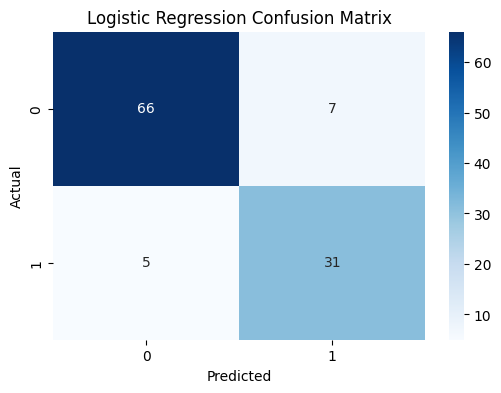

In [41]:
import matplotlib.pyplot as plt
import seaborn as sns

cm = confusion_matrix(y_test, y_pred_lr)

plt.figure(figsize=(6,4))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.title("Logistic Regression Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [42]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred_rf))
print("Precision:", precision_score(y_test, y_pred_rf))
print("Recall:", recall_score(y_test, y_pred_rf))
print("F1:", f1_score(y_test, y_pred_rf))

Accuracy: 0.9174311926605505
Precision: 0.9655172413793104
Recall: 0.7777777777777778
F1: 0.8615384615384616


In [43]:
import pandas as pd

importance_df = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf.feature_importances_
})

importance_df = importance_df.sort_values(
    by="Importance",
    ascending=False
)

importance_df.head(10)

,Feature,Importance
37,Follicle No. (R),0.183278
36,Follicle No. (L),0.125951
29,Skin darkening (Y/N),0.056597
27,Weight gain(Y/N),0.053453
28,hair growth(Y/N),0.050487
22,AMH(ng/mL),0.034437
9,Cycle length(days),0.026985
8,Cycle(R/I),0.026114
3,BMI,0.022917
32,Fast food (Y/N),0.021881


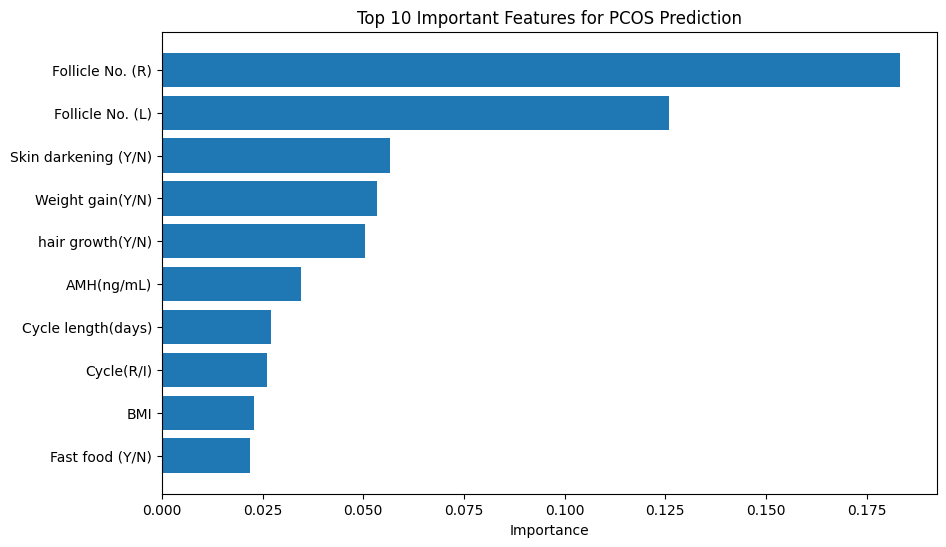

In [44]:
top_features = importance_df.head(10)

plt.figure(figsize=(10,6))

plt.barh(
    top_features["Feature"],
    top_features["Importance"]
)

plt.title("Top 10 Important Features for PCOS Prediction")
plt.xlabel("Importance")
plt.gca().invert_yaxis()

plt.show()

In [45]:
comparison = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Random Forest"
    ],
    "Accuracy": [
        accuracy_score(y_test, y_pred_lr),
        accuracy_score(y_test, y_pred_rf)
    ],
    "Precision": [
        precision_score(y_test, y_pred_lr),
        precision_score(y_test, y_pred_rf)
    ],
    "Recall": [
        recall_score(y_test, y_pred_lr),
        recall_score(y_test, y_pred_rf)
    ],
    "F1 Score": [
        f1_score(y_test, y_pred_lr),
        f1_score(y_test, y_pred_rf)
    ]
})

comparison

,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.889908,0.815789,0.861111,0.837838
1,Random Forest,0.917431,0.965517,0.777778,0.861538


In [46]:
best_model = comparison.sort_values(
    by="F1 Score",
    ascending=False
)

best_model.head(1)

,Model,Accuracy,Precision,Recall,F1 Score
1,Random Forest,0.917431,0.965517,0.777778,0.861538


In [47]:
import joblib

joblib.dump(
    rf,
    "../models/pcos_random_forest.pkl"
)

print("Model saved successfully!")

Model saved successfully!


In [48]:
loaded_model = joblib.load(
    "../models/pcos_random_forest.pkl"
)

sample_prediction = loaded_model.predict(
    X_test.iloc[:5]
)

print(sample_prediction)

[0 0 0 1 0]


# Conclusion

This project developed a machine learning system for PCOS prediction using clinical and lifestyle features.

Key Findings:

- Dataset Size: 541 patients
- Features Used: 41
- Missing values successfully handled
- Exploratory Data Analysis performed
- Logistic Regression Accuracy: 88.99%
- Random Forest Accuracy: 91.74%

Most Important Features:

1. Follicle No. (R)
2. Follicle No. (L)
3. Skin darkening
4. Weight gain
5. Hair growth
6. AMH levels

Random Forest achieved the best overall performance and was selected as the final model for PCOS prediction.

Future work may include:
- XGBoost implementation
- Hyperparameter tuning
- Deployment using Flask/Streamlit
- Integration into a healthcare screening application